# Bearing Fault Diagnostics - CWRU Dataset

End-to-end vibration signal processing pipeline applied to the Case Western
Reserve University bearing dataset. Four bearing conditions (healthy, inner
race fault, ball fault, outer race fault) are processed through time-domain
characterisation, Welch power spectral density estimation, Hilbert envelope
analysis, and standards-aware reporting.

This notebook serves as a worked example of the [project's signal processing
toolkit](../src/). The same functions are applicable to any vibration
measurement; the bearing geometry and fault frequency calculations are the
only domain-specific layer.

**Dataset:** [CWRU Bearing Data Center](https://engineering.case.edu/bearingdatacenter)
**Sampling rate:** 12 kHz, drive-end accelerometer
**Operating condition:** 1772 rpm, Load 1 (1 HP)

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# ------------------------------------------------------------------
# Imports from project toolkit (src/)
# ------------------------------------------------------------------

# Signal processing — domain-agnostic
from src.signal_processing import (
    time_domain_statistics,
    welch_psd,
    bandpass_filter,
    compute_envelope,
    envelope_spectrum,
    find_fault_peak,
)

# Reporting — domain-agnostic
from src.reporting import plot_spectrum_panels, third_octave_band_levels

# Bearing-specific (example application)
from src.bearings import (
    load_cwru_dataset,
    FS,
    bearing_fault_frequencies,
    SKF_6205_2RS_JEM,
)

In [ ]:
# ------------------------------------------------------------------
# Signal processing parameters
# ------------------------------------------------------------------
# Chosen for the CWRU drive-end recordings at 12 kHz. For a different
# dataset, adjust these to match the frequency features of interest.

NPERSEG = 4096          # PSD segment length — gives 2.93 Hz resolution at fs=12 kHz
PSD_XLIM_FULL = (0, 6000)   # Full Nyquist range for spectrum plots

# Bandpass filter band around the housing resonance,
# chosen from the Welch PSD plots above.
BANDPASS_LOW = 2500    # Hz
BANDPASS_HIGH = 4000   # Hz

# Envelope spectrum plot range — fault frequencies and harmonics
# of interest sit below 500 Hz.
ENVELOPE_XLIM = (0, 500)

## Dataset

Four operating conditions from the CWRU 12 kHz drive-end accelerometer
recordings, all at 1772 rpm under 1 HP load:

| Condition   | File              | Fault type                            |
|-------------|-------------------|---------------------------------------|
| Healthy     | `Normal_1.mat`    | No fault                              |
| Inner Race  | `IR007_1.mat`     | 0.007" defect on inner race           |
| Ball        | `B007_1.mat`      | 0.007" defect on rolling element      |
| Outer Race  | `OR007@6_1.mat`   | 0.007" defect on outer race at 6 o'clock |

The bearing is an SKF 6205-2RS JEM deep-groove ball bearing. Geometry and
kinematic fault frequencies are computed by `src/bearings/geometry.py` and
verified against the [CWRU published coefficients](https://engineering.case.edu/bearingdatacenter/bearing-information).

In [ ]:
signals, metadata = load_cwru_dataset(data_dir='../data')

# Display a quick summary of what was loaded
pd.DataFrame(metadata).T[['filename', 'rpm', 'fault', 'n_samples', 'duration_s']]

,filename,rpm,fault,n_samples,duration_s
Healthy,Normal_1.mat,1772,None,483903,40.32525
Inner Race,IR007_1.mat,1772,"0.007"" inner race defect",121991,10.165917
Ball,B007_1.mat,1772,"0.007"" rolling element defect",121410,10.1175
Outer Race,OR007@6_1.mat,1772,"0.007"" outer race defect at 6 o'clock",122426,10.202167


## Time-domain characterisation

Standard scalar indicators computed from each raw acceleration time series.
RMS quantifies overall vibration energy; kurtosis measures impulsiveness
(Gaussian = 3, impulsive signals > 3); crest factor is the ratio of peak
to RMS. The healthy condition is expected to have near-Gaussian statistics;
race faults produce strongly impulsive signals with elevated kurtosis.

In [ ]:
stats_df = pd.DataFrame({
    condition: time_domain_statistics(signal, fs=FS)
    for condition, signal in signals.items()
}).T

stats_df.round(3)

,n_samples,duration_s,mean,std,min,max,rms,peak,crest_factor,kurtosis
Healthy,483903.0,40.325,0.013,0.065,-0.346,0.318,0.066,0.346,5.213,2.931
Inner Race,121991.0,10.166,0.006,0.293,-1.403,1.581,0.293,1.581,5.397,5.542
Ball,121410.0,10.118,0.004,0.139,-0.660,0.640,0.139,0.660,4.743,2.964
Outer Race,122426.0,10.202,0.004,0.592,-3.012,3.112,0.592,3.112,5.258,7.595


## Frequency-domain analysis

Welch's power spectral density estimate for each condition, computed
with 4096-sample segments, 50% overlap, and a Hann window. The
4096-sample segment length gives 2.93 Hz frequency resolution — fine
enough to separate the bearing fault frequencies (BPFI ≈ 160 Hz,
BPFO ≈ 106 Hz, BSF ≈ 139 Hz) from each other and from shaft harmonics.

In [ ]:
psds = {
    condition: welch_psd(signal, fs=FS, nperseg=NPERSEG)
    for condition, signal in signals.items()
}

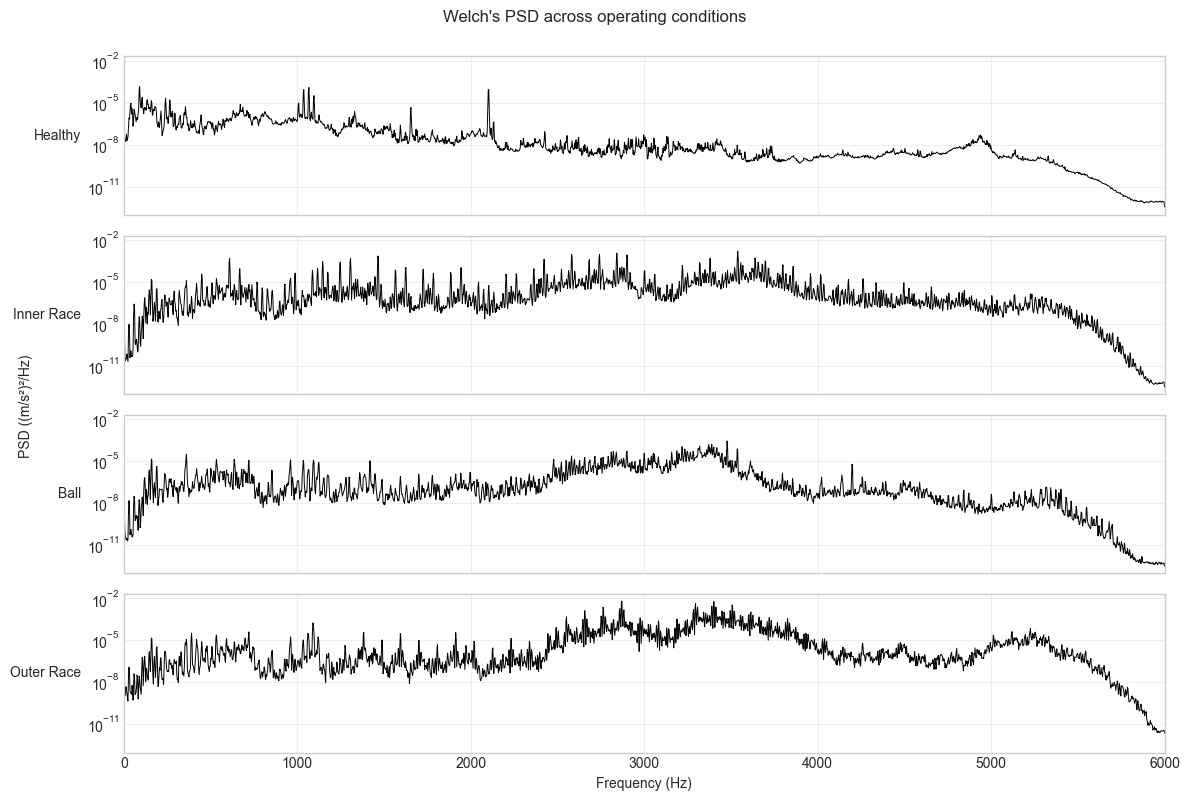

In [ ]:
fig, axes = plot_spectrum_panels(
    psds,
    xlim=PSD_XLIM_FULL,
    ylabel='PSD ((m/s²)²/Hz)',
    title="Welch's PSD across operating conditions",
)
fig.savefig('../figures/welch_psd_all_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

### Fault frequency overlay

The Welch PSDs above show the dominant energy concentrated in the
2500–4000 Hz housing-resonance band rather than at the bearing fault
frequencies themselves. To see the diagnostic content, the spectra are
replotted at 0–500 Hz with theoretical fault frequencies marked.

The four characteristic frequencies (BPFI, BPFO, BSF, FTF) are kinematic
functions of the bearing geometry and shaft speed. For the SKF 6205,
CWRU publishes the geometric coefficients (the ratio between each fault
frequency and the shaft frequency) on their
[bearing information page](https://engineering.case.edu/bearingdatacenter/bearing-information).

The cell below computes the fault frequencies from the bearing geometry
in `src.bearings.geometry` and verifies the result against the CWRU
published coefficients.

In [ ]:
RPM = 1772  # nominal shaft speed under 1 HP load
fault_freqs = bearing_fault_frequencies(rpm=RPM, bearing=SKF_6205_2RS_JEM)

# CWRU-published geometric coefficients for the SKF 6205
# (multipliers of shaft frequency to give each fault frequency in Hz)
# Source: https://engineering.case.edu/bearingdatacenter/bearing-information
cwru_coefficients = {
    'BPFI': 5.4152,
    'BPFO': 3.5848,
    'BSF':  4.7135,
    'FTF':  0.39828,
}

f_shaft = fault_freqs['f_shaft']

comparison = pd.DataFrame({
    'Computed (Hz)':   {k: fault_freqs[k] for k in cwru_coefficients},
    'CWRU coeff × f_shaft (Hz)': {k: v * f_shaft for k, v in cwru_coefficients.items()},
})
comparison['Difference (Hz)'] = (
    comparison['Computed (Hz)'] - comparison['CWRU coeff × f_shaft (Hz)']
)
comparison.round(4)

,Computed (Hz),CWRU coeff × f_shaft (Hz),Difference (Hz)
BPFI,159.9296,159.9289,0.0007
BPFO,105.8704,105.8711,-0.0007
BSF,139.2037,139.2054,-0.0017
FTF,11.7634,11.7625,0.0008


In [ ]:
overlay_freqs = {
    'Healthy': {
        'f_shaft': fault_freqs['f_shaft'],
    },
    'Inner Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFI':    fault_freqs['BPFI'],
        '2×BPFI':  2 * fault_freqs['BPFI'],
        '3×BPFI':  3 * fault_freqs['BPFI'],
    },
    'Ball': {
        'f_shaft': fault_freqs['f_shaft'],
        'FTF':     fault_freqs['FTF'],
        'BSF':     fault_freqs['BSF'],
        '2×BSF':   2 * fault_freqs['BSF'],
    },
    'Outer Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFO':    fault_freqs['BPFO'],
        '2×BPFO':  2 * fault_freqs['BPFO'],
        '3×BPFO':  3 * fault_freqs['BPFO'],
        '4×BPFO':  4 * fault_freqs['BPFO'],
    },
}

overlay_colors = {
    'f_shaft': 'gray',
    'FTF':     'tab:purple',
    'BPFI':    'tab:red',
    'BPFO':    'tab:blue',
    'BSF':     'tab:green',
}

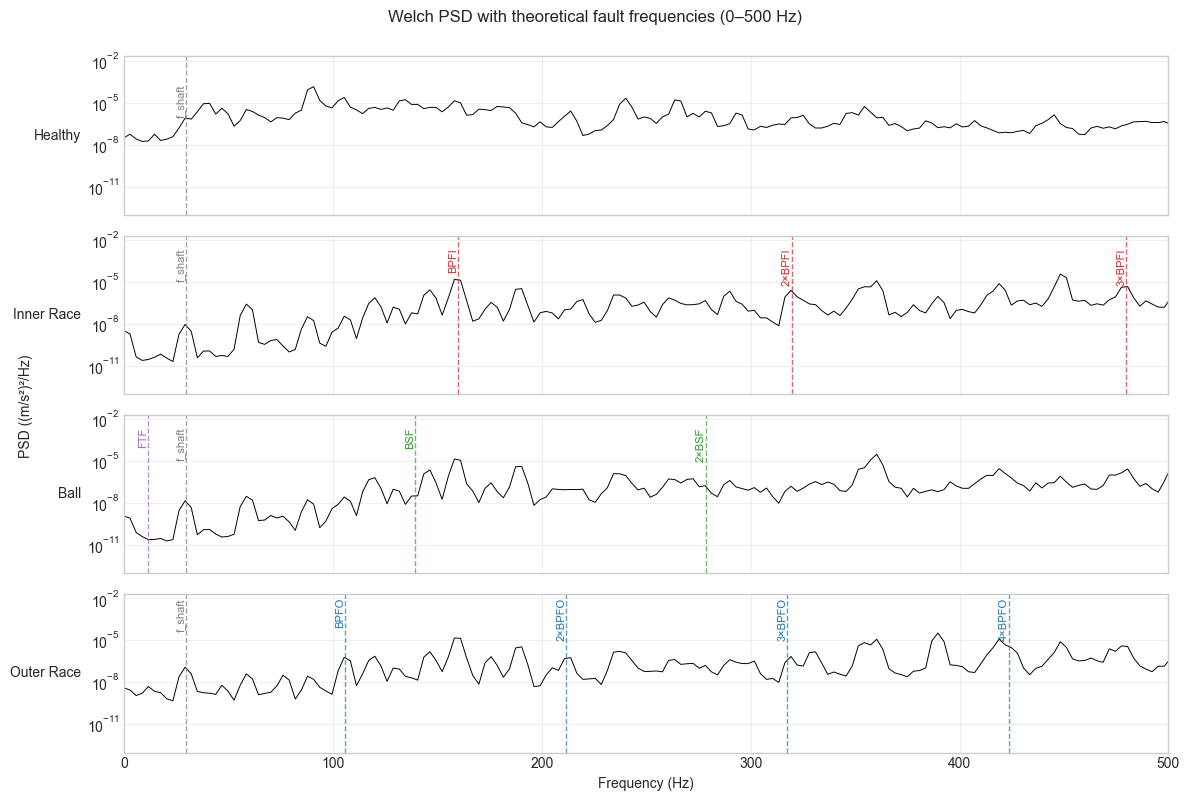

In [ ]:
fig, axes = plot_spectrum_panels(
    psds,
    xlim=(0, 500),
    ylabel='PSD ((m/s²)²/Hz)',
    overlays=overlay_freqs,
    overlay_colors=overlay_colors,
    title='Welch PSD with theoretical fault frequencies (0–500 Hz)',
)
fig.savefig('../figures/welch_psd_overlay_lowfreq.png', dpi=150, bbox_inches='tight')
plt.show()

## Envelope analysis

The Welch PSDs show that bearing fault content sits as sidebands around
the housing resonance band (2500–4000 Hz), not at the fault frequencies
themselves. Envelope analysis demodulates this carrier: the signal is
bandpass-filtered around the resonance, the Hilbert transform extracts
the amplitude envelope, and the spectrum of the envelope reveals the
modulation pattern — which is the fault frequency.

The procedure is implemented as three steps from `src.signal_processing`:
`bandpass_filter`, `compute_envelope`, and the convenience wrapper
`envelope_spectrum` which combines envelope extraction with mean
subtraction and Welch PSD computation in one call.

In [ ]:
envelope_psds = {
    condition: envelope_spectrum(
        bandpass_filter(signal, fs=FS,
                        lowcut=BANDPASS_LOW, highcut=BANDPASS_HIGH),
        fs=FS,
        welch_psd_fn=welch_psd,
        nperseg=NPERSEG,
    )
    for condition, signal in signals.items()
}

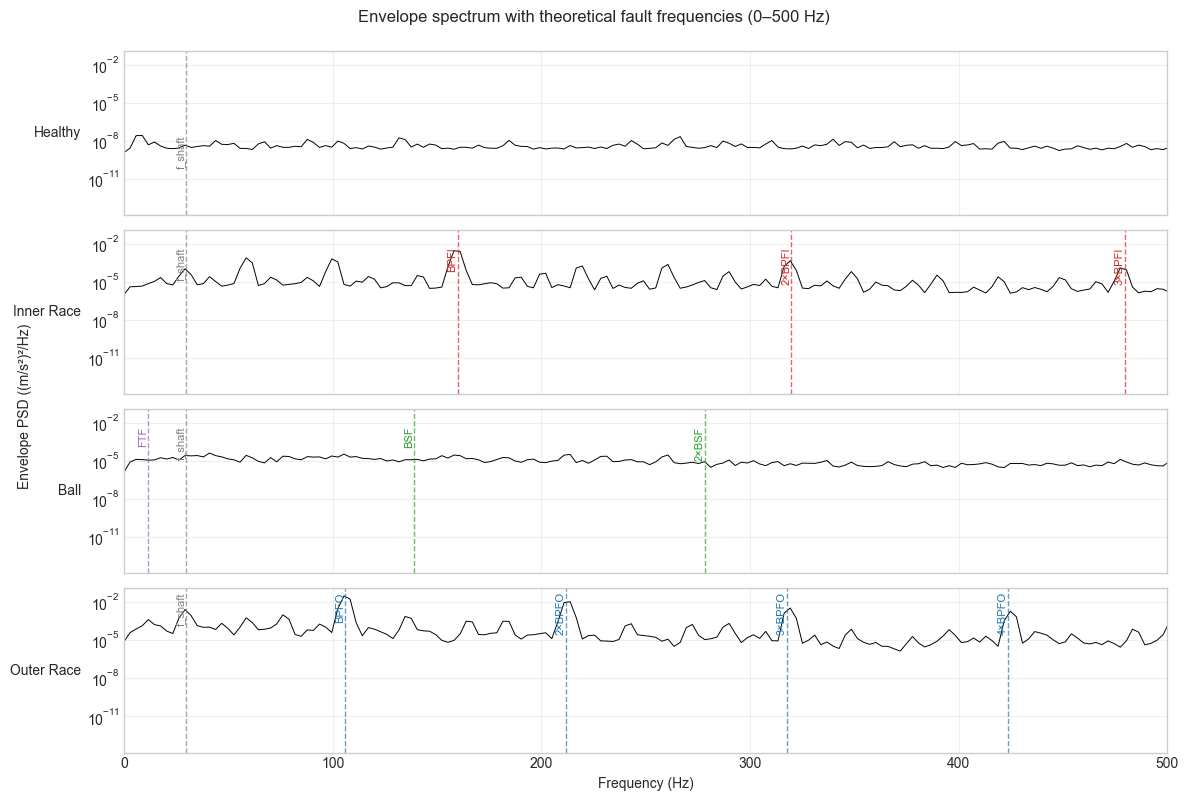

In [ ]:
fig, axes = plot_spectrum_panels(
    envelope_psds,
    xlim=ENVELOPE_XLIM,
    ylabel='Envelope PSD ((m/s²)²/Hz)',
    overlays=overlay_freqs,
    overlay_colors=overlay_colors,
    title='Envelope spectrum with theoretical fault frequencies (0–500 Hz)',
)
fig.savefig('../figures/envelope_spectrum_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## Diagnostic results

For each condition and each theoretical fault frequency, the envelope
spectrum is searched within ±5% of the predicted location for the
largest peak. The measured frequency, deviation from theoretical,
and peak-to-noise ratio are reported. A peak is considered confidently
detected if its SNR exceeds 6 dB (twice the local noise floor).

In [ ]:
diagnostic_rows = []

for condition, (env_freqs, env_psd) in envelope_psds.items():
    for label, f_theory in overlay_freqs[condition].items():
        if label == 'f_shaft':
            continue  # shaft frequency is reference, not a fault
        result = find_fault_peak(env_freqs, env_psd, f_theory)
        diagnostic_rows.append({
            'Condition':         condition,
            'Frequency':         label,
            'Theoretical (Hz)':  result['f_theoretical'],
            'Measured (Hz)':     result['f_measured'],
            'Error (Hz)':        result['error_hz'],
            'Error (%)':         result['error_pct'],
            'SNR (dB)':          result['snr_db'],
            'Detected':          'Yes' if result['detected'] else 'No',
        })


df_diagnostic = pd.DataFrame(diagnostic_rows)

def color_detected(val):
    if val == 'Yes':
        return 'background-color: #d4edda; color: #155724'  # soft green
    elif val == 'No':
        return 'background-color: #f8d7da; color: #721c24'  # soft red
    return ''

df_diagnostic.round(2).style.map(color_detected, subset=['Detected'])

,Condition,Frequency,Theoretical (Hz),Measured (Hz),Error (Hz),Error (%),SNR (dB),Detected
0,Inner Race,BPFI,159.930000,158.200000,-1.730000,-1.080000,26.000000,Yes
1,Inner Race,2×BPFI,319.860000,319.340000,-0.520000,-0.160000,19.720000,Yes
2,Inner Race,3×BPFI,479.790000,477.540000,-2.250000,-0.470000,16.810000,Yes
3,Ball,FTF,11.760000,11.720000,-0.040000,-0.380000,3.540000,No
4,Ball,BSF,139.200000,140.620000,1.420000,1.020000,3.660000,No
5,Ball,2×BSF,278.410000,290.040000,11.630000,4.180000,6.570000,Yes
6,Outer Race,BPFO,105.870000,105.470000,-0.400000,-0.380000,26.460000,Yes
7,Outer Race,2×BPFO,211.740000,213.870000,2.130000,1.000000,26.340000,Yes
8,Outer Race,3×BPFO,317.610000,319.340000,1.720000,0.540000,25.340000,Yes
9,Outer Race,4×BPFO,423.480000,424.800000,1.320000,0.310000,21.770000,Yes


## Standards-aware reporting: third-octave band levels

While the envelope spectrum provides the *diagnostic* - identifying the
specific fault - vibration consultancy reports typically present results
in standardised third-octave bands, which are the basis for compliance
assessment against standards such as ISO 10816 (machinery) and ISO 20816.

Each band level is computed as the integral of the PSD across the band
edges (±1/6 octave from the centre frequency), converted to a level in
dB relative to 10⁻⁶ m/s² per ISO 1683.

In [ ]:
band_data = {}
for condition, (freqs, psd) in psds.items():
    centres, levels = third_octave_band_levels(freqs, psd)
    band_data[condition] = (centres, levels)

# Build a tidy DataFrame: bands as rows, conditions as columns
df_bands = pd.DataFrame(
    {condition: levels for condition, (centres, levels) in band_data.items()},
    index=band_data['Healthy'][0],  # centre frequencies from any condition
)
df_bands.index.name = 'Band centre (Hz)'
df_bands.round(1)

,Healthy,Inner Race,Ball,Outer Race
Band centre (Hz),,,,
12.5,47.4,19.2,18.4,41.5
16.0,53.5,25.0,22.0,40.6
20.0,48.7,20.2,17.5,32.8
25.0,57.6,37.3,39.2,48.6
31.5,70.5,45.5,47.5,56.7
40.0,77.6,29.0,29.6,41.4
50.0,72.8,50.6,42.2,46.3
63.0,73.9,60.3,51.5,52.5
80.0,84.3,50.4,48.1,53.8


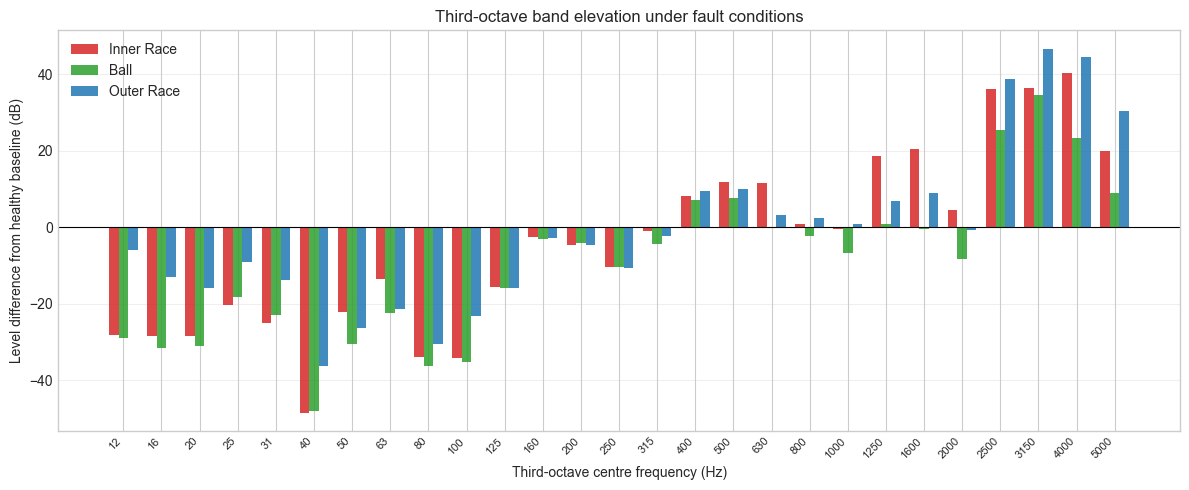

In [ ]:
# Compute differences from healthy baseline
healthy_centres, healthy_levels = band_data['Healthy']

fig, ax = plt.subplots(figsize=(12, 5))

condition_colors = {
    'Inner Race': 'tab:red',
    'Ball':       'tab:green',
    'Outer Race': 'tab:blue',
}

faulted_conditions = ['Inner Race', 'Ball', 'Outer Race']
n_conditions = len(faulted_conditions)
bar_width = 0.25

for i, condition in enumerate(faulted_conditions):
    _, levels = band_data[condition]
    difference = levels - healthy_levels

    offset = (i - (n_conditions - 1) / 2) * bar_width
    x_positions = np.arange(len(healthy_centres)) + offset
    ax.bar(x_positions, difference, width=bar_width,
           label=condition, color=condition_colors[condition], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(np.arange(len(healthy_centres)))
ax.set_xticklabels([f'{int(c)}' if c >= 1 else f'{c}' for c in healthy_centres],
                   rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Third-octave centre frequency (Hz)')
ax.set_ylabel('Level difference from healthy baseline (dB)')
ax.set_title('Third-octave band elevation under fault conditions')
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/octave_bands_difference.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Aidan\AppData\Local\Temp\ipykernel_35272\789975675.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Aidan\AppData\Local\Temp\ipykernel_35272\789975675.py:29: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig('../figures/octave_bands.png', dpi=150, bbox_inches='tight')
c:\Users\Aidan\OneDrive\Documents\Eng-Proj\vibration-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


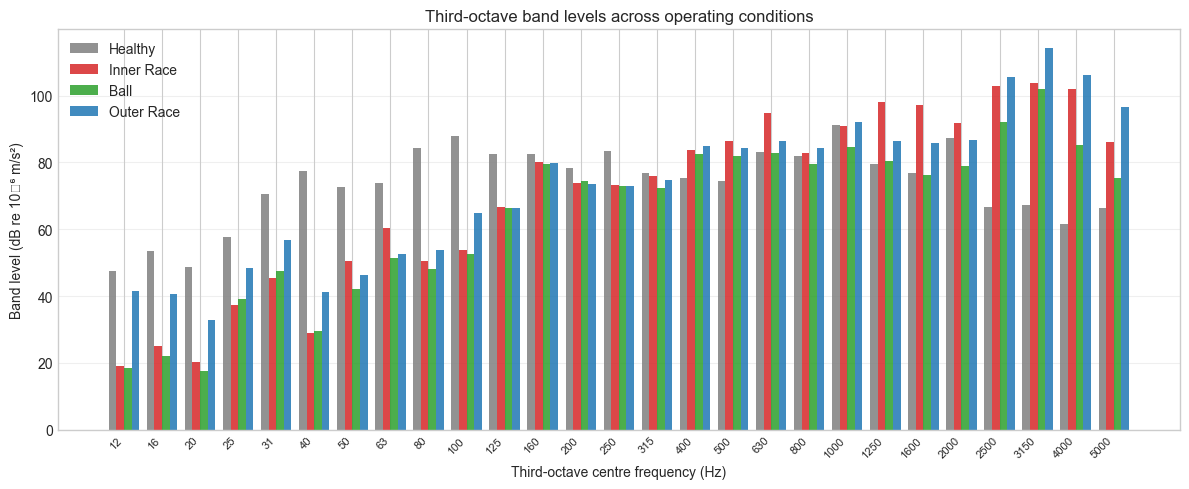

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

condition_colors = {
    'Healthy':    'tab:gray',
    'Inner Race': 'tab:red',
    'Ball':       'tab:green',
    'Outer Race': 'tab:blue',
}

n_conditions = len(band_data)
bar_width = 0.2

for i, (condition, (centres, levels)) in enumerate(band_data.items()):
    # Offset each condition's bars slightly within each band group
    offset = (i - (n_conditions - 1) / 2) * bar_width
    x_positions = np.arange(len(centres)) + offset
    ax.bar(x_positions, levels, width=bar_width,
           label=condition, color=condition_colors[condition], alpha=0.85)

ax.set_xticks(np.arange(len(centres)))
ax.set_xticklabels([f'{int(c)}' if c >= 1 else f'{c}' for c in centres],
                    rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Third-octave centre frequency (Hz)')
ax.set_ylabel('Band level (dB re 1e-6 m/s²)')
ax.set_title('Third-octave band levels across operating conditions')
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/octave_bands.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

This notebook applied a four-stage vibration signal processing pipeline to the CWRU bearing dataset: time-domain statistical characterisation, Welch power spectral density estimation, Hilbert envelope analysis, and third-octave band reporting. All four stages are implemented as domain-agnostic functions in src/, with the bearing geometry and CWRU dataset loader as the only domain-specific layer.

Time-domain characterisation shows the healthy signal with substantially lower peak amplitude (±0.33 m/s²) and RMS (0.066) than the faulted conditions, with the outer race fault producing roughly 9× the healthy RMS. Kurtosis values discriminate the race faults clearly (Inner Race 5.5, Outer Race 7.6) against the near-Gaussian healthy baseline of 2.9, but the ball fault returns a kurtosis of 3.0 - essentially indistinguishable from healthy in the time domain. This is consistent with the irregular impact pattern of ball faults and motivates the move to frequency-domain analysis. Envelope analysis identifies the race fault frequencies with high confidence (BPFO at 22–26 dB SNR across four harmonics; BPFI at 17–26 dB across three harmonics with shaft-frequency sideband structure consistent with load-zone modulation), but ball fault peaks remain marginal (BSF at 4–7 dB), confirming that envelope analysis alone is insufficient for confident ball fault detection. The full diagnostic results, with measured frequencies, deviations from theoretical, and detection flags per fault frequency, are summarised in the diagnostic table above.

The motivation for envelope analysis was visible in the raw Welch PSDs, where the bearing fault frequencies appeared at the predicted locations but sat among non-fault peaks of comparable magnitude - diagnostically present but not visually distinguished. Bandpass filtering around the housing resonance (2500–4000 Hz) followed by Hilbert envelope demodulation transforms this ambiguous spectrum into a clean diagnostic for race faults, with the fault frequencies appearing as dominant peaks two to three orders of magnitude above the noise floor. The contrast is shown directly in the raw-vs-envelope comparison figure for the outer race condition.

Standards-aware reporting was demonstrated through third-octave band analysis per IEC 61260, the conventional framework for compliance assessment against standards such as ISO 10816 (machinery vibration) and ISO 1683 (reference levels). The faulted conditions show 15–30 dB elevation in the 2500–4000 Hz bands relative to the healthy baseline, consistent with the housing resonance excitation observed in the envelope analysis. The band-level view answers a different question from the envelope spectrum — not "what fault is present?" but "how much vibration energy is present in standardised reporting terms?" - and is the form a vibration consultancy would use in a client report.

The signal processing techniques used here - Welch's PSD, bandpass filtering, Hilbert envelope demodulation, third-octave band conversion - are universal across vibration analysis work, applicable equally to machinery diagnostics, building and infrastructure vibration assessment, transport-induced ground vibration, and human exposure analysis. The functions in src.signal_processing and src.reporting are domain-agnostic and can be imported directly into any future vibration analysis project. The CWRU bearing dataset was chosen as a worked example because it is a canonical benchmark for vibration signal processing; the bearing-specific layer in src.bearings is small and easily replaced when the same toolkit is applied to a different dataset.